# Module 09 — What this toy stack cannot do yet

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vvknyn/self-driving-ai-course/blob/main/notebooks/09_cutting_edge_research.ipynb)

Modules 00–08 are a mini modular stack. This notebook does not add a `modules/09` folder, and it does not train a driver. It is a reading seminar: what that code actually computes, what published papers claim beyond it, and how to pick one paper for this week.

When a section has code, predict the printout, run the cell, then read the numbers. The cells are NumPy and Matplotlib. They should finish in well under two minutes on a Colab CPU.


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

print("numpy", np.__version__)
print("matplotlib", matplotlib.__version__)
print("course modules imported: no")


numpy 2.4.4
matplotlib 3.11.2
course modules imported: no


## 1. What Modules 00–08 actually compute

A real stack has to turn cameras into a decision that changes when the scene changes. Read the integrated step before you read the paper list. `FullFSDPipeline.step` in `modules/08_capstone_fsd/pipeline.py` does all of the following on one call:

- It runs the HydraNet **backbone** only (`p3`). The lane, freespace, vehicle, and traffic-light heads do not run.
- It runs Lift-Splat-Shoot and the occupancy network under `torch.no_grad()`. `__init__` builds those modules with their default initial weights. There is no `load_state_dict`.
- It builds tracker detections from `ground_truth_obstacles`.
- It plans a quintic lattice with `lane_centerline_y=0.0`. The `VectorLane` created in `__init__` is not read inside `step`.
- It applies Stanley steering and a PID speed command on a kinematic bicycle.
- `occ_probs` is a local variable. It is not returned and it is not passed to the planner.

The folders above that function are not empty. They compute the things in the table. The gap is what the integrated step is willing to use.

| Module | What that folder computes | What the capstone step uses |
| :--- | :--- | :--- |
| 00 | A small CNN on real 64×64 crops, four classes, accuracy and per-class recall. Focal loss is in `losses.py`. | Nothing. The capstone does not import it. |
| 01 | Pinhole intrinsics, extrinsics, a flat-ground homography, a three-camera stitch, and pitch error versus distance. | A scripted rig (`K`, `R`, `T`) handed to Lift-Splat-Shoot. |
| 02 | A shared backbone and four heads. `train_hydranet.py` runs 10 optimizer steps on `torch.randn` images and random targets, with an uncertainty weighting loss. | The backbone feature `p3` only. |
| 03 | A categorical depth per pixel, then a splat into a metric bird's-eye grid. The file cites Philion and Fidler. | The BEV tensor, as the input to occupancy. The planner never sees it. |
| 04 | A ConvGRU memory. `forward` returns `occ_probs` shaped `(B, 1, NX, NY, NZ)` and a velocity field. | Both tensors are computed. Neither is an input to the tracker. |
| 05 | A Kalman tracker on 2D points, and one cubic `y = c0 + c1 x + c2 x^2 + c3 x^3`. | Tracker inputs are the ground-truth points. The cubic is not read in `step`. |
| 06 | Quintic boundary curves and a lattice scored against point obstacles that have a radius. | This planner runs, on those ground-truth points, with the centerline fixed at `y = 0`. |
| 07 | A kinematic bicycle, Stanley steering, and PID speed. Stanley here is the cross-track rule in `controllers.py`, not a tire model. | This controller runs on the lattice path. |
| 08 | The wiring above. The returned dict is pose, steer, throttle, cross-track error, track count, waypoints, and cost. | There is no camera loss in that dict. |

Papers that match those folders, not the open-problem list yet: focal loss ([Lin et al.](https://arxiv.org/abs/1708.02002)), Lift-Splat-Shoot ([Philion and Fidler](https://arxiv.org/abs/2008.05711)), and the Stanley PDF ([Thrun et al.](https://robots.stanford.edu/papers/thrun.stanley05.pdf)). The PDF is the Stanford copy. This notebook does not re-measure that desert run.

**Predict.** The next cell sketches the interface, not `FullFSDPipeline` itself. Occupancy is all zeros, then all ones. The obstacle list stays `x = 10`, `y = 1.2`. Which of the two printed arrays changes: the planner input, the occupancy checksum, or both?


In [2]:
def capstone_interface(occ_probs, ground_truth_obstacles):
    # Sketch of pipeline.py step(), not a call to that class.
    # Detections are built from ground_truth_obstacles only.
    checksum = float(np.sum(occ_probs))
    detections = np.array(
        [[obs["x"], obs["y"]] for obs in ground_truth_obstacles],
        dtype=float,
    )
    return detections, checksum

obstacles = [{"x": 10.0, "y": 1.2}]
det_a, sum_a = capstone_interface(np.zeros((1, 1, 4, 4, 2)), obstacles)
det_b, sum_b = capstone_interface(np.ones((1, 1, 4, 4, 2)), obstacles)
print("planner sees (occ zeros):", det_a.tolist())
print("planner sees (occ ones): ", det_b.tolist())
print("same planner input?", bool(np.array_equal(det_a, det_b)))
print("occupancy checksum, zeros:", sum_a)
print("occupancy checksum, ones: ", sum_b)


planner sees (occ zeros): [[10.0, 1.2]]
planner sees (occ ones):  [[10.0, 1.2]]
same planner input? True
occupancy checksum, zeros: 0.0
occupancy checksum, ones:  32.0


The planner input is `[[10.0, 1.2]]` in both calls, and `same planner input?` is `True`. The occupancy checksum goes from `0` to `32` because the tensor is shape `(1, 1, 4, 4, 2)` and the second call fills it with ones (`1×1×4×4×2 = 32`). Changing occupancy did not change the plan's inputs.

That is the perception–planning gap in this repo. The next papers ask what happens if the plan is allowed to depend on the camera.


## 2. End-to-end driving

Three different claims get called "end to end." They do not delete the same pieces.

**PilotNet** (Bojarski et al., [End to End Learning for Self-Driving Cars](https://arxiv.org/abs/1604.07316)) trains a CNN from a front-camera image to a steering command. The abstract says the network was never explicitly trained to find the outline of the road, and that the system runs at 30 frames per second. Intermediate lane detection, path planning, and control are not outputs.

**TransFuser** (Chitta et al., [Imitation with Transformer-Based Sensor Fusion for Autonomous Driving](https://arxiv.org/abs/2205.15997)) is also imitation, but the inputs are image and LiDAR, fused by attention at several resolutions. The abstract says this cuts average collisions per kilometer by 48% relative to geometry-based fusion, on CARLA. An earlier conference version (Prakash, Chitta, and Geiger, [Multi-Modal Fusion Transformer](https://arxiv.org/abs/2104.09224)) reports a 76% collision reduction against geometry-based fusion on its own setup. Those are two write-ups, not one number measured twice. Neither number is a nuScenes score.

**UniAD** (Hu et al., [Planning-oriented Autonomous Driving](https://arxiv.org/abs/2212.10156)) keeps a stack of tasks (track, map, motion, occupancy, plan) and connects them with queries so the training target is planning. The abstract says the alternative, separate heads, can accumulate error. It does not print a scalar in the abstract. Do not invent one.

A Tesla-style claim, as it shows up in product talks, is that one network maps video to controls and drops a separate HD map and a hand-written planner. There is no peer-reviewed Tesla paper in this notebook. The citable neighbors of that claim are PilotNet (pixels to steer), TransFuser (imitation with two sensors), and UniAD (modules kept, planning used as the goal). A product talk is not a table you can re-run.

**Predict.** The next cell fits a linear map from an 8×8 image to a steer command on four examples. In every example the only bright pixels are a lane column. The fit is minimum-norm least squares, not an epoch loop. Then an obstacle pixel that was dark in all four examples turns on, at row 2, column 1, with the lane still in column 4. Does the linear steer change? The modular rule adds a second term that depends on the obstacle column. Does that steer change?


In [3]:
def scene(lane_col, obstacle=None):
    img = np.zeros((8, 8), dtype=float)
    img[:, lane_col] = 1.0
    if obstacle is not None:
        img[obstacle] = 1.0
    return img.ravel()

def modular_steer(lane_col, obstacle_col=None):
    steer = (lane_col - 3.5) / 3.5
    if obstacle_col is not None:
        steer = steer + (3.5 - obstacle_col) / 3.5
    return float(steer)

cols = np.array([2, 3, 4, 5])
X = np.stack([scene(int(c)) for c in cols])
y = (cols - 3.5) / 3.5
w, residuals, rank, singular = np.linalg.lstsq(X, y, rcond=None)
obstacle = (2, 1)
a_clear = float(scene(4) @ w)
a_obs = float(scene(4, obstacle=obstacle) @ w)
w_obs = float(w.reshape(8, 8)[obstacle])
m_clear = modular_steer(4)
m_obs = modular_steer(4, obstacle_col=1)
print("least-squares rank:", int(rank))
print(f"weight on the obstacle pixel: {w_obs:.4f}")
print(f"linear steer, lane only:     {a_clear:.4f}")
print(f"linear steer, obstacle on:   {a_obs:.4f}")
print(f"linear steer changed by:     {a_obs - a_clear:.4f}")
print(f"modular steer, lane only:    {m_clear:.4f}")
print(f"modular steer, obstacle on:  {m_obs:.4f}")


least-squares rank: 4
weight on the obstacle pixel: 0.0000
linear steer, lane only:     0.1429
linear steer, obstacle on:   0.1429
linear steer changed by:     0.0000
modular steer, lane only:    0.1429
modular steer, obstacle on:  0.8571


The linear steer is `0.1429` with the lane alone and `0.1429` with the obstacle pixel on. The change is `0.0000`. The weight on that pixel is `0.0000`: a minimum-norm fit puts no weight on a pixel that was zero in every training row, and the residual on those four lane columns can be fit without it. The modular steer moves from `0.1429` to `0.8571` because the second term looks at column 1.

Same pixels, two answers. PilotNet's claim is the first kind of map: one function, trained on the steer the human used. UniAD's claim is closer to the second shape: keep an intermediate object, and make the plan depend on it. The toy does not show that either paper's network works. It shows why the two claims are not the same sentence.

de Haan, Jayaraman, and Levine ([Causal Confusion in Imitation Learning](https://arxiv.org/abs/1905.11979)) describe the failure mode of the first map: more information can make a cloned policy worse when the fit latches onto the wrong cause. Codevilla et al. ([Exploring the Limitations of Behavior Cloning for Autonomous Driving](https://arxiv.org/abs/1904.08980)) is the scaling version: cloning can do maneuvers you did not hand-write, and it still breaks on dataset bias, dynamic objects, and the lack of a causal model.


## 3. Occupancy, vectors, and maps

Three representations fail on different scenes. The numbers below are this notebook's geometry, not a benchmark.

**Occupancy.** A cell is marked occupied when the object covers at least half of the cell's area. A thin pole can sit in the cell and stay under that threshold.

**Vectors.** Module 05 stores one cubic in forward distance `x`. A fork is two laterals at the same `x`. A cubic fit to the left branch cannot also be the right branch.

**Maps.** A stored cubic is yesterday's road. If construction shifts the lane by a constant, every query of the old coefficients is off by that shift until someone rebuilds the map.

**Predict.** The pole is 0.10 m wide and the cell is 1 m by 1 m. At a threshold of 0.5, is the cell occupied? The cubic is fit only to the left branch. At `x = 30` m, which branch should the curve miss by multiple meters?


pole 0.10 m → fraction 0.100 → occupied? False
car  1.60 m → fraction 1.000 → occupied? True
max |cubic - left branch|  = 0.188 m
max |cubic - right branch| = 5.436 m
at x=30 m, cubic 2.736 m, left 2.700 m, right -2.700 m
stored map at x=20 m: 0.400 m
shifted road at x=20 m: 1.900 m
map error at x=20 m: 1.500 m


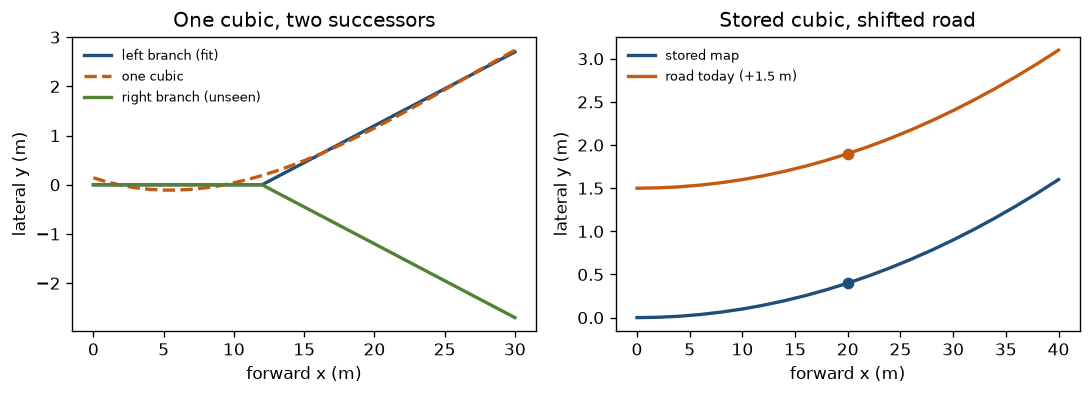

In [4]:
def covered_fraction(width_m, voxel_m=1.0):
    span = min(width_m, voxel_m)
    return (span * voxel_m) / (voxel_m ** 2)

threshold = 0.5
frac_pole = covered_fraction(0.10)
frac_car = covered_fraction(1.60)
print(f"pole 0.10 m → fraction {frac_pole:.3f} → occupied? {frac_pole >= threshold}")
print(f"car  1.60 m → fraction {frac_car:.3f} → occupied? {frac_car >= threshold}")

x = np.linspace(0.0, 30.0, 31)
y_left = np.where(x < 12.0, 0.0, 0.15 * (x - 12.0))
y_right = np.where(x < 12.0, 0.0, -0.15 * (x - 12.0))
coef = np.polyfit(x, y_left, 3)
y_hat = np.polyval(coef, x)
err_left = float(np.max(np.abs(y_hat - y_left)))
err_right = float(np.max(np.abs(y_hat - y_right)))
print(f"max |cubic - left branch|  = {err_left:.3f} m")
print(f"max |cubic - right branch| = {err_right:.3f} m")
print(f"at x=30 m, cubic {y_hat[-1]:.3f} m, left {y_left[-1]:.3f} m, right {y_right[-1]:.3f} m")

x_map = np.linspace(0.0, 40.0, 21)
y_old = 0.001 * x_map**2
shift_m = 1.5
y_new = y_old + shift_m
coef_map = np.polyfit(x_map, y_old, 3)
y_map_20 = float(np.polyval(coef_map, 20.0))
y_today_20 = float(np.polyval(np.polyfit(x_map, y_new, 3), 20.0))
print(f"stored map at x=20 m: {y_map_20:.3f} m")
print(f"shifted road at x=20 m: {y_today_20:.3f} m")
print(f"map error at x=20 m: {y_today_20 - y_map_20:.3f} m")

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.4))
axes[0].plot(x, y_left, color="#1f4e79", lw=2.0, label="left branch (fit)")
axes[0].plot(x, y_hat, color="#c45911", lw=2.0, ls="--", label="one cubic")
axes[0].plot(x, y_right, color="#548235", lw=2.0, label="right branch (unseen)")
axes[0].set_xlabel("forward x (m)")
axes[0].set_ylabel("lateral y (m)")
axes[0].set_title("One cubic, two successors")
axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(x_map, y_old, color="#1f4e79", lw=2.0, label="stored map")
axes[1].plot(x_map, y_new, color="#c45911", lw=2.0, label="road today (+1.5 m)")
axes[1].scatter([20.0], [y_map_20], color="#1f4e79", zorder=3)
axes[1].scatter([20.0], [y_today_20], color="#c45911", zorder=3)
axes[1].set_xlabel("forward x (m)")
axes[1].set_ylabel("lateral y (m)")
axes[1].set_title("Stored cubic, shifted road")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


The pole covers `0.100` of the cell and is marked empty. The car covers `1.000` and is marked occupied. The pole is still in the cell. Occ3D (Tian et al., [Occ3D](https://arxiv.org/abs/2304.14365)) is the benchmark version of this complaint: boxes miss shape, and occupancy is useful when it also carries semantics. Module 04's head is a sigmoid over voxels. It does not produce that benchmark label.

The cubic's worst miss on the branch it was fit to is `0.188` m. The kink at 12 m is not a cubic, so even the observed branch is not exact. Its worst miss on the other branch is `5.436` m. At `x = 30` m the curve says `2.736` m, the left branch is `2.700` m, and the right branch is `-2.700` m. OpenLane-V2 (Wang et al., [OpenLane-V2](https://arxiv.org/abs/2304.10440)) asks for that missing structure: relations among lanes and traffic elements, on 2,000 annotated scenes, not a single polyline score.

The stored map at `x = 20` m says `0.400` m. The shifted road is at `1.900` m. The error is `1.500` m, the construction shift. A map that is not rebuilt does not notice.

VAD (Jiang et al., [VAD](https://arxiv.org/abs/2303.12077)) argues the other way: a dense occupancy raster is expensive and drops instance identity, and a vector scene is a better planner input. Their abstract's 29.0% is a relative collision-rate reduction for VAD-Base, and 2.5× / 9.3× are speed claims. This notebook did not re-run VAD. The fork above is the failure mode of a vector that is too small (one cubic). A grid can miss a pole. A vector can miss a fork. A map can be stale. Those are three different bugs.


## 4. Open problems, one paper each

Each row is one problem this toy stack does not solve, and one paper. The URL is the arXiv abstract. Read that page before you trust a blog summary of it.

| Problem | Where the toy stack stops | Paper |
| :--- | :--- | :--- |
| Perception is not trained for the plan | Capstone `step` runs the backbone, Lift-Splat-Shoot, and occupancy, then plans from ground-truth obstacle points. | [Yihan Hu et al., Planning-oriented Autonomous Driving (UniAD)](https://arxiv.org/abs/2212.10156) |
| A pixels-to-steer fit can ignore a cause it never had to use | The ten-line least-squares policy in this notebook does not move when an unseen obstacle pixel turns on. | [Pim de Haan, Dinesh Jayaraman, and Sergey Levine, Causal Confusion in Imitation Learning](https://arxiv.org/abs/1905.11979) |
| Behavior cloning does not cover the driving distribution | Module 00 classifies 64×64 crops. It does not imitate a control trace. | [Felipe Codevilla et al., Exploring the Limitations of Behavior Cloning for Autonomous Driving](https://arxiv.org/abs/1904.08980) |
| Camera depth is the weak point of lift-and-splat BEV | Module 03 predicts a categorical depth and splats features. A bad depth smears the grid. | [Yinhao Li et al., BEVDepth: Acquisition of Reliable Depth for Multi-view 3D Object Detection](https://arxiv.org/abs/2206.10092) |
| Boxes drop shape, and empty-versus-occupied drops the class | Module 04 returns a sigmoid occupancy and a velocity field, not a semantic occupancy benchmark. | [Xiaoyu Tian et al., Occ3D: A Large-Scale 3D Occupancy Prediction Benchmark for Autonomous Driving](https://arxiv.org/abs/2304.14365) |
| One cubic lane is not a topology | Module 05 is a single cubic. The capstone builds one with fixed coefficients and does not read it in `step`. | [Huijie Wang et al., OpenLane-V2: A Topology Reasoning Benchmark for Unified 3D HD Mapping](https://arxiv.org/abs/2304.10440) |
| A dense grid is a heavy planner input and drops instance identity | Module 06 scores point obstacles with a radius. It does not consume the occupancy tensor. | [Bo Jiang et al., VAD: Vectorized Scene Representation for Efficient Autonomous Driving](https://arxiv.org/abs/2303.12077) |
| Open-loop error is not a closed-loop drive | Module 08 returns cross-track error on a scripted bicycle. That is a wiring check. | [Daniel Dauner et al., NAVSIM: Data-Driven Non-Reactive Autonomous Vehicle Simulation and Benchmarking](https://arxiv.org/abs/2406.15349) |
| Geometry-only image and LiDAR fusion struggles in dense traffic | The course stack is vision-shaped code plus a kinematic controller. It does not fuse LiDAR. | [Kashyap Chitta et al., TransFuser: Imitation with Transformer-Based Sensor Fusion for Autonomous Driving](https://arxiv.org/abs/2205.15997) |
| A log does not contain the future you did not drive | Nothing in Modules 00–08 rolls out a counterfactual video. | [Anthony Hu et al., GAIA-1: A Generative World Model for Autonomous Driving](https://arxiv.org/abs/2309.17080) |
| A driving question is a graph, not one caption | The capstone return dict has pose, steer, and waypoints. It has no scene graph to query. | [Chonghao Sima et al., DriveLM: Driving with Graph Visual Question Answering](https://arxiv.org/abs/2312.14150) |
| Task losses in different units need a weight | Module 02's train script uses an uncertainty weighting loss for 10 steps on random tensors. The capstone never calls it. | [Alex Kendall, Yarin Gal, and Roberto Cipolla, Multi-Task Learning Using Uncertainty to Weigh Losses for Scene Geometry and Semantics](https://arxiv.org/abs/1705.07115) |

Two papers from earlier sections are the method side of rows you already have code for, so they are not a second citation in the table: Lift-Splat-Shoot for the BEV geometry Module 03 implements, and focal loss for the class-imbalance loss Module 00 implements.

### Eight steps, using only the BEVDepth abstract

The routine, applied to Yinhao Li et al. ([BEVDepth](https://arxiv.org/abs/2206.10092)). Steps the abstract does not answer stay blank on purpose.

1. **Question.** Camera-based 3D detection is limited by depth that is not good enough.
2. **Figure 1.** Not in the abstract. Open the PDF before you draw the tensors.
3. **Notation.** The abstract does not give shapes. Module 03's depth bins are not this paper's shapes. Copy the paper's, from the paper.
4. **Novelty.** Explicit depth supervision, a camera-aware depth module, and a depth refinement module, instead of depth that is only implied by the detection loss.
5. **Evidence.** The abstract states "60.9% NDS on the challenging nuScenes test set." The next sentence says that, for the first time, the NDS score of a camera model reaches 60%. This notebook did not open the table.
6. **Ablation.** The abstract does not name which row was removed. Open the PDF.
7. **Code.** The abstract, as hosted on the abs page, does not include a commit hash.
8. **Limitation.** Not in the abstract. Read the last section before you quote 60.9 as a reason to change Module 03.

UniAD's abstract argues that the stack should be optimized for planning, and it states no scalar. The evidence step for UniAD is to open the PDF, not to recall a number from memory.


## 5. Numbers that appear in the abstracts

The next cell prints a table of scalars that are written in the abstracts fetched for this notebook. It plots only two of them: BEVFormer and BEVDepth both state a camera-model NDS on the nuScenes **test** set. Everything else is a different quantity (a relative reduction, a speedup, a frame rate, a dataset size, a competition count) and stays in the table.

BEVFormer's abstract also says its result is 9.0 NDS points above the previous best at the time of that paper. That 9.0 is not `60.9 - 56.9`. Do not subtract the two bars and call the difference a comparison those authors ran.

**Predict.** Which rows share a metric and a split, and so can share an axis? Which rows are relative reductions and must not be drawn as if they were NDS?


paper                            arXiv        on the NDS axis? value
BEVFormer                        2203.17270   yes              56.9% NDS
    quote: 56.9% in terms of NDS metric on the nuScenes test set
BEVFormer                        2203.17270   no               9.0 NDS points vs that paper's previous best
    quote: 9.0 points higher than previous best arts
BEVDepth                         2206.10092   yes              60.9% NDS
    quote: 60.9% NDS on the challenging nuScenes test set
VAD                              2303.12077   no               29.0% relative collision-rate reduction; 2.5× speed
    quote: VAD-Base, greatly reduces the average collision rate by 29.0% and runs 2.5x faster
VAD                              2303.12077   no               up to 9.3× speed
    quote: a lightweight variant, VAD-Tiny, greatly improves the inference speed (up to 9.3x)
TransFuser                       2205.15997   no               48% relative reduction in collisions per km
    quote: 

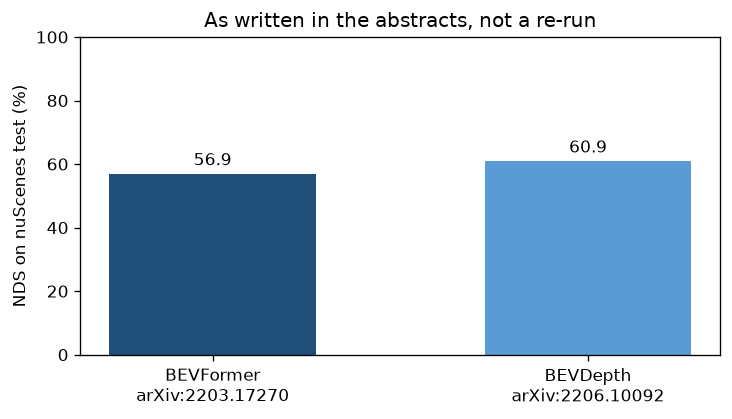

In [5]:
METRICS = [
    {
        'paper': 'BEVFormer',
        'arxiv': '2203.17270',
        'quote': '56.9% in terms of NDS metric on the nuScenes test set',
        'value_label': '56.9% NDS',
        'plot': True,
        'plot_value': 56.9,
    },
    {
        'paper': 'BEVFormer',
        'arxiv': '2203.17270',
        'quote': '9.0 points higher than previous best arts',
        'value_label': "9.0 NDS points vs that paper's previous best",
        'plot': False,
        'plot_value': None,
    },
    {
        'paper': 'BEVDepth',
        'arxiv': '2206.10092',
        'quote': '60.9% NDS on the challenging nuScenes test set',
        'value_label': '60.9% NDS',
        'plot': True,
        'plot_value': 60.9,
    },
    {
        'paper': 'VAD',
        'arxiv': '2303.12077',
        'quote': 'VAD-Base, greatly reduces the average collision rate by 29.0% and runs 2.5x faster',
        'value_label': '29.0% relative collision-rate reduction; 2.5× speed',
        'plot': False,
        'plot_value': None,
    },
    {
        'paper': 'VAD',
        'arxiv': '2303.12077',
        'quote': 'a lightweight variant, VAD-Tiny, greatly improves the inference speed (up to 9.3x)',
        'value_label': 'up to 9.3× speed',
        'plot': False,
        'plot_value': None,
    },
    {
        'paper': 'TransFuser',
        'arxiv': '2205.15997',
        'quote': 'Compared to geometry-based fusion, TransFuser reduces the average collisions per kilometer by 48%',
        'value_label': '48% relative reduction in collisions per km',
        'plot': False,
        'plot_value': None,
    },
    {
        'paper': 'TransFuser (conference version)',
        'arxiv': '2104.09224',
        'quote': 'reducing collisions by 76% compared to geometry-based fusion',
        'value_label': '76% relative collision reduction',
        'plot': False,
        'plot_value': None,
    },
    {
        'paper': 'PilotNet',
        'arxiv': '1604.07316',
        'quote': 'The system operates at 30 frames per second (FPS)',
        'value_label': '30 FPS',
        'plot': False,
        'plot_value': None,
    },
    {
        'paper': 'OpenLane-V2',
        'arxiv': '2304.10440',
        'quote': 'OpenLane-V2 consists of 2,000 annotated road scenes',
        'value_label': '2,000 scenes (dataset size)',
        'plot': False,
        'plot_value': None,
    },
    {
        'paper': 'NAVSIM',
        'arxiv': '2406.15349',
        'quote': '143 teams submitted 463 entries',
        'value_label': '143 teams, 463 entries',
        'plot': False,
        'plot_value': None,
    },
]
print(f"{'paper':<32} {'arXiv':<12} {'on the NDS axis?':<16} value")
for row in METRICS:
    flag = "yes" if row["plot"] else "no"
    print(f"{row['paper']:<32} {row['arxiv']:<12} {flag:<16} {row['value_label']}")
    print(f"    quote: {row['quote']}")

plotted = [row for row in METRICS if row["plot"]]
fig, ax = plt.subplots(figsize=(6.2, 3.6))
labels = [f"{row['paper']}\narXiv:{row['arxiv']}" for row in plotted]
values = [row["plot_value"] for row in plotted]
bars = ax.bar(labels, values, color=["#1f4e79", "#5b9bd5"], width=0.55)
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.5,
        f"{value:.1f}",
        ha="center",
        va="bottom",
    )
ax.set_ylim(0, 100)
ax.set_ylabel("NDS on nuScenes test (%)")
ax.set_title("As written in the abstracts, not a re-run")
fig.tight_layout()
plt.show()


The axis has two bars because two abstracts name the same metric and the same split: BEVFormer 56.9 NDS and BEVDepth 60.9 NDS, both on nuScenes test, both as camera models, in [Zhiqi Li et al.](https://arxiv.org/abs/2203.17270) and [Yinhao Li et al.](https://arxiv.org/abs/2206.10092). They were not trained in one experiment for this chart. The vertical axis starts at 0 so a four-point gap stays a four-point gap.

UniAD is missing from the chart because its abstract does not state an NDS. The 29.0%, 48%, and 76% figures are relative reductions inside their own papers, against those papers' own baselines. PilotNet's 30 FPS is a runtime sentence. OpenLane-V2's 2,000 is a count of scenes. NAVSIM's 143 and 463 count a 2024 challenge. None of those belong on an NDS axis.

If a blog quotes a UniAD or TransFuser number that is not in the list above, it came from a table this notebook did not copy. Go open that table, and write down the dataset and the split before you repeat the number.


## 6. How to pick a paper this week

Pick the failure you can point at in the repo, then one PDF.

| If your question is… | Read this first |
| :--- | :--- |
| Why does the plan ignore occupancy? | [UniAD](https://arxiv.org/abs/2212.10156) |
| Why does a pixels-to-steer policy ignore an obstacle? | [PilotNet](https://arxiv.org/abs/1604.07316), then [de Haan et al.](https://arxiv.org/abs/1905.11979) |
| Why is Module 03's depth the risky part? | [Lift, Splat, Shoot](https://arxiv.org/abs/2008.05711), then [BEVDepth](https://arxiv.org/abs/2206.10092) |
| Why is one cubic not a lane graph? | [OpenLane-V2](https://arxiv.org/abs/2304.10440) |
| Why is a cross-track number not a driving score? | [NAVSIM](https://arxiv.org/abs/2406.15349) |

One paper is a week. Use the eight steps from section 4. Fill this before you open a second PDF:

```text
Paper:
Question (one sentence):
Module hook (a file under modules/00–08):
Evidence (dataset, split, and the number, or "abstract gives none"):
Limitation (from the paper, or "not in the abstract"):
What I will not claim:
```

Stop when those six lines are full. A notation table with tensor shapes counts as part of the question, and it has to come from the PDF. Dashboard telemetry in the Module 08 studio is simulated. It is not a row in that evidence line.

The order that matches the stack you built: geometry (Lift-Splat-Shoot, then BEVDepth), then occupancy (Occ3D), then planning as the training target (UniAD), then topology or closed-loop evaluation if that is the hole you care about. Depth on one paper beats a folder of abstracts.
